In [20]:
import tensorflow as tf 
from tensorflow.keras.datasets import imdb 
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense 
import matplotlib.pyplot as plt

In [21]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train)) 
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [22]:
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len) 
x_test = pad_sequences(x_test, maxlen=max_len) 

print("Shape after padding:", x_train.shape)

Shape after padding: (25000, 200)


In [23]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64), 
    Dense(1, activation='sigmoid')
]) 

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile( 
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy'] 
)

In [25]:
history = model.fit( 
    x_train, y_train, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.2 
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.6026 - loss: 0.6466 - val_accuracy: 0.6720 - val_loss: 0.5994
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8200 - loss: 0.4043 - val_accuracy: 0.6846 - val_loss: 0.5971
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8996 - loss: 0.2544 - val_accuracy: 0.8060 - val_loss: 0.5003
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9747 - loss: 0.0816 - val_accuracy: 0.7884 - val_loss: 0.6316
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9919 - loss: 0.0324 - val_accuracy: 0.7638 - val_loss: 0.7638


In [26]:
loss, accuracy = model.evaluate(x_test, y_test) 
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7598 - loss: 0.7825 
Test Accuracy: 0.7598400115966797


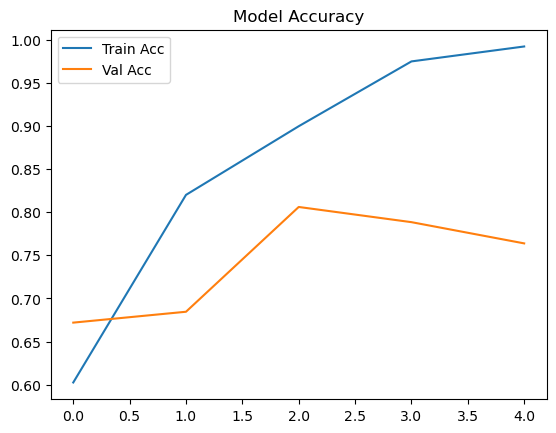

In [27]:
plt.plot(history.history['accuracy'], label='Train Acc') 
plt.plot(history.history['val_accuracy'], label='Val Acc') 
plt.legend() 
plt.title("Model Accuracy") 
plt.show()

In [28]:
from tensorflow.keras.datasets import imdb 
from tensorflow.keras.preprocessing.text import Tokenizer

word_index = imdb.get_word_index() 
word_index = {k: (v + 3) for k, v in word_index.items()} 
word_index["<PAD>"] = 0 
word_index["<START>"] = 1 
word_index["<UNK>"] = 2 
word_index["<UNUSED>"] = 3 

tokenizer = Tokenizer(num_words=vocab_size) 
tokenizer.word_index = word_index

In [29]:
user_review = input("Type your movie review: ").lower() 

sequence = tokenizer.texts_to_sequences([user_review]) 
padded = pad_sequences(sequence, maxlen=max_len) 

prediction = model.predict(padded, verbose=0) 

sentiment = "Positive ￿" if prediction[0][0] > 0.5 else "Negative ￿" 

print("\nProbability:", prediction[0][0]) 
print("Sentiment:", sentiment)

Type your movie review:  The "Terrible Adaptation" Review: "The script as a whole is terrible… Fans of the books will be angry and disappointed. They will leave the theater in droves and generate horrible word of mouth".



Probability: 0.00022673272
Sentiment: Negative ￿
